# SEGMENT3D — headless IFT-SC delineation of one meristem tile (Colab reproduction)

**Paper:** T.V. Spina, J. Stegmaier, A.X. Falcão, E. Meyerowitz, A. Cunha,
*SEGMENT3D: A web-based application for collaborative segmentation of 3D images used in the shoot apical meristem*, IEEE ISBI 2018, DOI [10.1109/ISBI.2018.8363600](https://doi.org/10.1109/ISBI.2018.8363600).
The readable full text is the authors' preprint [arXiv:1710.09933v1](https://arxiv.org/abs/1710.09933).

**Author code:** [`bzjin/SEGMENT3D`](https://github.com/bzjin/SEGMENT3D) pinned at commit `3d48a0d70cbebf3740e89b798b327facf6881dea` (JavaScript browser app; no license file present — reuse terms are with the authors).

**Scope (partial demonstration, executed):** SEGMENT3D is an interactive browser tool; its scientific core is
IFT-SC — an Image-Foresting-Transform segmentation by seed competition — run on 60³ tiles of a confocal
meristem image, optionally correcting a pre-segmentation from seeds at the *geodesic centers* of its labels
(paper §2.1–2.2). This notebook replays exactly that correction step, **headless**, on the repository's
embedded sample `data/tile_00417.raw` with its pre-segmentation `data/tile_pre_seg_00417.raw`:
it runs the **authors' actual pinned JavaScript** (IFT library + `DelineationAlg`) under Node.js, and
visualizes/validates the result in Python. GUI-only parts (WebGL rendering, scribble drawing, Django server,
multi-user sessions, STAPLE consensus) are out of scope. A single-tile run does not verify the paper's
dataset-level user studies.

**AI-assisted glue (Japanese summary):**
**本ノートブックは AI が作成したグルーコード（THREE.js の最小シムとドライバ）を含みます。** 科学計算そのものは
著者らのリポジトリの JavaScript を**無修正のまま**実行します（commit `3d48a0d70cbebf3740e89b798b327facf6881dea`）。著者はこの Colab 実装を
提供していないため、実行例と検証項目はこちらで確認しましたが、未検証の挙動については保証されません。

**Status:** executed end-to-end in a fresh Colab CPU runtime (see the validation record at the bottom).

## Runtime selection (CPU) — 実行環境の選択

**Select `Runtime → Change runtime type → CPU`.** The method is a 262k-voxel graph algorithm
(bucket-queue IFT); it needs no GPU and no heavy downloads (< 1 MB total). End-to-end run time is a few
minutes on a fresh runtime, dominated by the downloads.
**推奨ランタイムは CPU です。GPU は不要で、ダウンロード合計は 1 MB 未満、所要時間は数分です。**
Press *Run all*; the notebook fails loudly (assertions) if any downloaded byte fails verification.

In [ ]:
import shutil, subprocess, sys

print("Python:", sys.version.split()[0])

node = shutil.which("node")
if node is None:
    # Fallback: bounded apt install of Node.js (only if the image lacks it).
    print("node not found; installing nodejs via apt ...")
    subprocess.run(["apt-get", "-qq", "update"], check=True, timeout=300)
    subprocess.run(["apt-get", "-qq", "install", "-y", "nodejs"], check=True, timeout=600)
    node = shutil.which("node")
if node is None:
    raise RuntimeError("Node.js is required to run the authors' pinned JavaScript but is unavailable.")
print("node:", subprocess.run(["node", "--version"], capture_output=True, text=True, check=True).stdout.strip())

Python: 3.13.16
node: v20.19.0


## Inputs: the embedded sample tile and the authors' pinned code — 入力データとコードの入手

Downloaded **inside Colab** from `raw.githubusercontent.com` at the pinned commit `3d48a0d70cbebf3740e89b798b327facf6881dea`:
- `data/tile_00417.raw` — 60×60×60 uint8 confocal meristem tile (216,000 bytes).
- `data/tile_pre_seg_00417.raw` — its pre-segmentation label volume (216,000 bytes), referenced as the `label`
  of tile_00417 in the repository's `images.json`.
- 17 author JavaScript files (`DelineationAlg.js` + `ift/*.js`) that implement IFT-SC.

Every file is verified against its Git **blob SHA-1** (`sha1("blob <size>\\0" + content)`) and size from the
pinned commit's tree before use; the cell raises on any mismatch.
**すべてのファイルは pinned commit から取得し、Git blob SHA-1 とサイズを検証してから使います。**

In [ ]:
import hashlib
import pathlib
import urllib.request

COMMIT = "3d48a0d70cbebf3740e89b798b327facf6881dea"
BASE = f"https://raw.githubusercontent.com/bzjin/SEGMENT3D/{COMMIT}"
# path -> (size bytes, git blob sha1) recorded from the pinned commit tree.
MANIFEST = {
    "data/tile_00417.raw": [
        216000,
        "dbb680ef2bcc11da4d4dc48190730701d765712f"
    ],
    "data/tile_pre_seg_00417.raw": [
        216000,
        "5e9b1c87b0629b4e2f97ed6d262e564abda578ba"
    ],
    "static/crowd/workers/script/js/DelineationAlg.js": [
        896,
        "0bb5bfa37de1ae702ab9f2aff6a8ccb1884cd273"
    ],
    "static/crowd/workers/script/js/ift/iftAdjacency.js": [
        6083,
        "4fd60d2d2298fcac9b7b3a9b1e777815a9f07f25"
    ],
    "static/crowd/workers/script/js/ift/iftBMap.js": [
        962,
        "695eb8a530b1ed18cda4cc573c6a5b70a8d99877"
    ],
    "static/crowd/workers/script/js/ift/iftCommon.js": [
        5762,
        "7bd4722fbb55d6bbf3e35408730a70af2edd85bc"
    ],
    "static/crowd/workers/script/js/ift/iftGQueue.js": [
        10929,
        "b4066e3b1a3485979e5470edf154a35f6827521d"
    ],
    "static/crowd/workers/script/js/ift/iftImage.js": [
        23496,
        "13eb68b0e479cdc070c9a58c7a65d577e397cc9e"
    ],
    "static/crowd/workers/script/js/ift/iftImageForest.js": [
        4408,
        "8e75d50a82a7f6609beb9505501835abf9b578ba"
    ],
    "static/crowd/workers/script/js/ift/iftInterpolation.js": [
        8279,
        "a0e12dde1ded8a2235e42fde71ab6260f6890f96"
    ],
    "static/crowd/workers/script/js/ift/iftLabeledSet.js": [
        5640,
        "55b21bd50bd690e4d77677c1e3ad00ab97e9b40f"
    ],
    "static/crowd/workers/script/js/ift/iftMatrix.js": [
        2212,
        "25be288c7783c90fbce439f896bcaa37802b65ba"
    ],
    "static/crowd/workers/script/js/ift/iftMemory.js": [
        885,
        "0a928351e71e59a41068b5f48c31e50c8a4c3475"
    ],
    "static/crowd/workers/script/js/ift/iftRegion.js": [
        3030,
        "7068eb6ba05263d011f1e9ea71535a9868c3999c"
    ],
    "static/crowd/workers/script/js/ift/iftRepresentation.js": [
        2679,
        "bcd6df2ae6079284ab9c900bc29a764c8ccf93a9"
    ],
    "static/crowd/workers/script/js/ift/iftSeeds.js": [
        3150,
        "83026a8e0d05a10bd8630b86add30378f6c30200"
    ],
    "static/crowd/workers/script/js/ift/iftSegmentation.js": [
        10786,
        "bdb4fa814f5a19d7b8a3d3b851ec227789ec63fc"
    ],
    "static/crowd/workers/script/js/ift/iftSet.js": [
        3832,
        "51977ee9030bb5a67edca9ae10b3d6a408c3bb92"
    ],
    "static/crowd/workers/script/js/ift/iftSort.js": [
        1120,
        "6471ced7b3cadce0ca77d0cd95933c95c1f17c38"
    ]
}

REPO = pathlib.Path("/content/seg3d/repo")
REPO.mkdir(parents=True, exist_ok=True)


def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()


for rel, (size, blob) in MANIFEST.items():
    dest = REPO / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    data = urllib.request.urlopen(f"{BASE}/{rel}", timeout=120).read()
    assert len(data) == size, f"{rel}: expected {size} bytes, got {len(data)}"
    assert git_blob_sha1(data) == blob, f"{rel}: blob sha mismatch"
    dest.write_bytes(data)
    print(f"verified {rel} ({size} B)")

print("\nAll", len(MANIFEST), "files match commit", COMMIT)

verified data/tile_00417.raw (216000 B)


verified data/tile_pre_seg_00417.raw (216000 B)


verified static/crowd/workers/script/js/DelineationAlg.js (896 B)


verified static/crowd/workers/script/js/ift/iftAdjacency.js (6083 B)


verified static/crowd/workers/script/js/ift/iftBMap.js (962 B)


...

verified static/crowd/workers/script/js/ift/iftRepresentation.js (2679 B)


verified static/crowd/workers/script/js/ift/iftSeeds.js (3150 B)


verified static/crowd/workers/script/js/ift/iftSegmentation.js (10786 B)


verified static/crowd/workers/script/js/ift/iftSet.js (3832 B)


verified static/crowd/workers/script/js/ift/iftSort.js (1120 B)

All 19 files match commit 3d48a0d70cbebf3740e89b798b327facf6881dea


## Input preview: the tile with its pre-segmentation — 入力プレビュー

Three orthogonal mid-slices of `tile_00417` (grayscale, confocal signal) with the **pre-segmentation region
borders** (`tile_pre_seg_00417`) overlaid in red. This is the reference annotation the app would load for
*interactive correction*; the delineation below must stay consistent with it.
**赤線は事前セグメンテーション `tile_pre_seg_00417` の領域境界です。以下の再区画結果はこれと比較します。**

tile_00417: dtype=uint8 shape=(60, 60, 60)  min=4 max=255 mean=66.3
pre-seg labels: 43 regions (max label 255), background voxels=18150


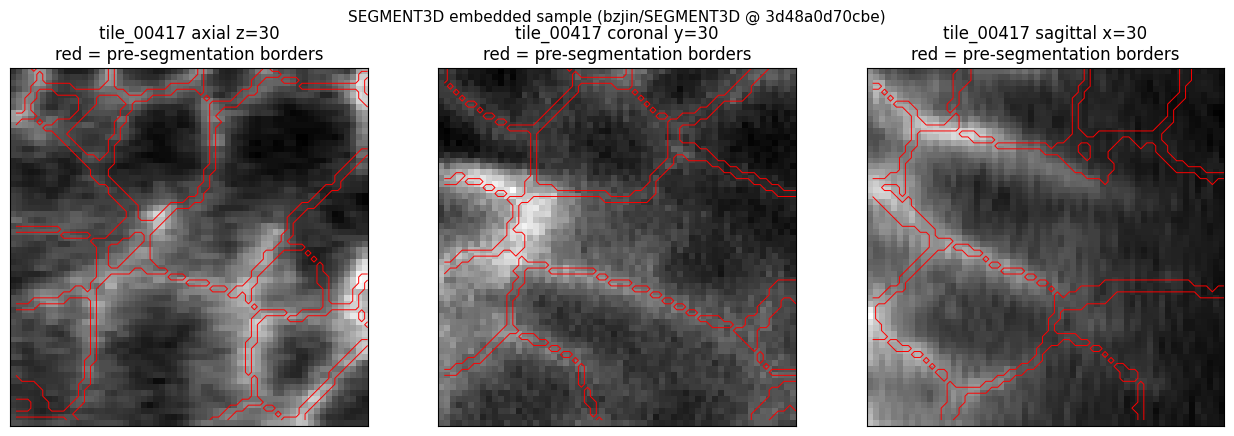

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

DATA = "/content/seg3d/repo/data"
img = np.fromfile(f"{DATA}/tile_00417.raw", dtype=np.uint8).reshape(60, 60, 60)
pre = np.fromfile(f"{DATA}/tile_pre_seg_00417.raw", dtype=np.uint8).reshape(60, 60, 60)

print("tile_00417: dtype=uint8 shape=(60, 60, 60)  min=%d max=%d mean=%.1f" % (img.min(), img.max(), img.mean()))
print("pre-seg labels: %d regions (max label %d), background voxels=%d"
      % (len(np.unique(pre)) - (1 if 0 in pre else 0), pre.max(), int((pre == 0).sum())))


def borders(lbl):
    b = np.zeros(lbl.shape, bool)
    b[:-1, :, :] |= lbl[:-1, :, :] != lbl[1:, :, :]
    b[:, :-1, :] |= lbl[:, :-1, :] != lbl[:, 1:, :]
    b[:, :, :-1] |= lbl[:, :, :-1] != lbl[:, :, 1:]
    return b


pre_b = borders(pre)
views = [(img[30], pre_b[30], "axial z=30"), (img[:, 30, :], pre_b[:, 30, :], "coronal y=30"),
         (img[:, :, 30], pre_b[:, :, 30], "sagittal x=30")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (sl, pb, title) in zip(axes, views):
    ax.imshow(sl.T, cmap="gray", origin="lower")
    ax.contour(pb.T.astype(float), levels=[0.5], colors="red", linewidths=0.7, origin="lower")
    ax.set_title(f"tile_00417 {title}\nred = pre-segmentation borders")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("SEGMENT3D embedded sample (bzjin/SEGMENT3D @ " + COMMIT[:12] + ")", fontsize=11)
fig.tight_layout()
plt.savefig("/content/seg3d/input_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## Headless driver: the authors' algorithm on the app's delineation path — headless ドライバ

The app's delineation path, traced in the pinned source (`static/crowd/workers/script/js/`):
1. `ImageData.scaleImageFor3DVisualization` rescales 60³ → 64³ (next power of two): the image with trilinear
   `iftResizeImage`, the label with nearest-neighbor `iftScaleImageByNearestNeighbor`.
1b. **Compatibility fix (documented):** the shipped pre-segmentation uses sparse label ids (43 regions but max
   id 255), whereas `iftGeodesicCenters` documents its input as *"an image labelled from 0 to n"* (contiguous);
   fed sparse ids it would emit one bogus seed per missing id at voxel 0 (observed in our first diagnostic run:
   255 seeds, spurious regions). The driver therefore relabels values to the contiguous ids 1..43 before
   seeding — a value-preserving precondition fix, not an algorithm change; region boundaries are untouched.
2. `Cose3D.createScene`: `images.json` declares no gradient file for tile_00417, so the delineation forest is
   built on the **raw tile itself**: `new DelineationAlg(img, iftSpheric(1.0))` (6-adjacency).
3. `loadLabelFile` → `iftSeedsFromLabelAtGeodesicCenters(label, 2.0)` — one seed per region at its most
   interior voxel (geodesic center), radius `min(2, √distance-to-border)`.
4. `Scribble.scribblePointsToVoxels` turns each JSON seed into a sphere of voxels (radius in voxels,
   first-come-wins, most-interior regions first).
5. `DelineationAlg.delineate` → `iftDiffWatershed` (IFT-SC): path value = max cost along the path over the
   6-adjacent graph; one bucket per intensity value; FIFO tie-breaking.

The cell below defines a **minimal `THREE.Vector3` shim** (the only three.js API used on this headless path)
and the driver, and writes them to the Colab VM. Both are AI-written glue; **no author file is modified** —
the driver only calls the downloaded author functions.
**THREE.js の最小シムとドライバ（AI 生成のグルーコード）を書き出します。著者コードは無改変で、呼び出すだけです。**

In [ ]:
import pathlib

SHIM_JS = r"""// Minimal THREE shim (AI-written glue). Only Vector3 operations used by the
// pinned SEGMENT3D ift scripts on this headless path. No rendering occurs.
class Vector3 {
  constructor(x = 0, y = 0, z = 0) { this.x = x; this.y = y; this.z = z; }
  set(x, y, z) { this.x = x; this.y = y; this.z = z; return this; }
  add(v) { this.x += v.x; this.y += v.y; this.z += v.z; return this; }
  sub(v) { this.x -= v.x; this.y -= v.y; this.z -= v.z; return this; }
  addVectors(a, b) { this.x = a.x + b.x; this.y = a.y + b.y; this.z = a.z + b.z; return this; }
  subVectors(a, b) { this.x = a.x - b.x; this.y = a.y - b.y; this.z = a.z - b.z; return this; }
  multiplyScalar(s) { this.x *= s; this.y *= s; this.z *= s; return this; }
  divideScalar(s) { return this.multiplyScalar(1 / s); }
  distanceTo(v) { const dx = this.x - v.x, dy = this.y - v.y, dz = this.z - v.z;
                  return Math.sqrt(dx * dx + dy * dy + dz * dz); }
  clone() { return new Vector3(this.x, this.y, this.z); }
  round() { this.x = Math.round(this.x); this.y = Math.round(this.y); this.z = Math.round(this.z); return this; }
  floor() { this.x = Math.floor(this.x); this.y = Math.floor(this.y); this.z = Math.floor(this.z); return this; }
  negate() { return this.multiplyScalar(-1); }
  length() { return Math.sqrt(this.x * this.x + this.y * this.y + this.z * this.z); }
  crossVectors(a, b) { const ax = a.x, ay = a.y, az = a.z;
                       this.x = ay * b.z - az * b.y; this.y = az * b.x - ax * b.z; this.z = ax * b.y - ay * b.x;
                       return this; }
}
const THREE = { Vector3 };
"""

DRIVER_JS = r"""// --- driver (AI-written glue). Every scientific operation below calls the
// authors' pinned SEGMENT3D JavaScript unmodified; this file only loads the
// data and replays the app's delineation path without the GUI. ---
const fs = require('fs');
const DATA = '/content/seg3d/repo/data';
const OUT = '/content/seg3d/out';
fs.mkdirSync(OUT, { recursive: true });

function loadRawU8(path, expected) {
  const buf = fs.readFileSync(path);
  if (buf.length !== expected) throw new Error(path + ': expected ' + expected + ' bytes, got ' + buf.length);
  return new Uint8Array(buf);
}
function writeRawU8(path, img) {
  for (let p = 0; p < img.n; p++) {
    if (img.val[p] < 0 || img.val[p] > 255) throw new Error('label out of u8 range: ' + img.val[p]);
  }
  fs.writeFileSync(path, Buffer.from(Array.from(img.val, (v) => v & 0xFF)));
}

// 1) Load the 60^3 tile and its pre-segmentation (uint8 volumes).
const N60 = 60 * 60 * 60;
const img60 = new iftImage(60, 60, 60, loadRawU8(DATA + '/tile_00417.raw', N60));
const preseg60 = new iftImage(60, 60, 60, loadRawU8(DATA + '/tile_pre_seg_00417.raw', N60));

// 1b) The shipped pre-segmentation uses sparse label ids (43 regions but max id
//     255), while iftGeodesicCenters documents its input as "an image labelled
//     from 0 to n" (contiguous ids); with sparse ids it would emit one bogus
//     seed per missing id at voxel 0. Restore the documented precondition with
//     an explicit value-preserving relabeling; results are mapped back below.
const fwd = new Int32Array(256).fill(0);  // original id -> contiguous id
let next = 0;
for (let p = 0; p < preseg60.n; p++) {
  const v = preseg60.val[p];
  if (v > 0 && fwd[v] === 0) { next++; fwd[v] = next; }
}
const preseg60c = iftCreateImage(60, 60, 60);
for (let p = 0; p < preseg60.n; p++) preseg60c.val[p] = fwd[preseg60.val[p]];

// 2) Scale to 64^3 exactly as the app does (ImageData.scaleImageFor3DVisualization):
//    image by trilinear iftResizeImage, label by nearest neighbor.
const img64 = iftResizeImage(img60, 64, 64, 64);
const preseg64 = iftScaleImageByNearestNeighbor(preseg60c, 64 / 60, 64 / 60, 64 / 60);

// 3) IFT-SC forest on the raw tile: images.json declares no gradient file for
//    tile_00417, so Cose3D.createScene uses the raw image itself as the cost map.
const delineationAlg = new DelineationAlg(img64, iftSpheric(1.0));

// 4) Seeds at the geodesic centers of the pre-segmentation (author iftSeeds.js),
//    expanded to the sphere of voxels the app's Scribble pipeline produces
//    (Scribble.scribblePointsToVoxels with radius in voxels, first-come-wins).
const J = iftSeedsFromLabelAtGeodesicCenters(preseg64, 2.0);
const selected = iftCreateImage(64, 64, 64);
iftSetImage(selected, IFT_NIL);
const seeds = [];
for (let i = 0; i < J.elem.length; i++) {
  const r = !iftAlmostZero(J.radius[i]) ? J.radius[i] : 1.0; // loadScribblesFromJson rule
  const A = iftSpheric(r);
  const c = iftGetVoxelCoord(preseg64, J.elem[i]);
  for (let k = 0; k < A.n; k++) {
    const v = new THREE.Vector3(c.x + A.dx[k], c.y + A.dy[k], c.z + A.dz[k]);
    if (iftValidVoxel(preseg64, v)) {
      const p = iftGetVoxelIndex(preseg64, v);
      if (selected.val[p] < 0) { // most-interior regions are seeded first
        selected.val[p] = J.label[i];
        seeds.push({ elem: v, label: J.label[i], marker: i + 1 });
      }
    }
  }
}

// 5) IFT-SC delineation (DelineationAlg.delineate -> iftDiffWatershed).
delineationAlg.delineate(seeds, null);
const result64 = delineationAlg.fst.label;

// 6) Snapshot the pre-correction result (the forest label map is updated in
//    place by delineate) and export it at the original 60^3 grid.
const result64Before = iftCreateImage(64, 64, 64);
iftCopyImageInplace(result64, result64Before);
const result60 = iftScaleImageByNearestNeighbor(result64Before, 60 / 64, 60 / 64, 60 / 64);

// 7) Per-region Dice of the re-delineation vs the (contiguous) pre-segmentation.
function diceTable(A, B, nregions) {
  const inter = new Int32Array(nregions + 1), sa = new Int32Array(nregions + 1), sb = new Int32Array(nregions + 1);
  for (let p = 0; p < A.n; p++) {
    const a = A.val[p], b = B.val[p];
    if (a > 0) { sa[a]++; if (a === b) inter[a]++; }
    if (b > 0) sb[b]++;
  }
  const rows = [];
  for (let lb = 1; lb <= nregions; lb++) {
    if (sa[lb] + sb[lb] > 0) rows.push({ lb: lb, dice: 2 * inter[lb] / (sa[lb] + sb[lb]) });
  }
  return rows;
}
const diceBefore = diceTable(preseg64, result64, next);

// 8) Demonstrate the paper's interactive correction (DIFT-SC differential update):
//    add ONE user scribble inside the worst-agreement region, at the centroid of
//    the part of it that the re-delineation mislabeled, then re-delineate. This
//    calls the same author path (DelineationAlg.delineate -> iftDiffWatershed)
//    that the app's delineate() uses for every scribble edit.
const diceBeforeMean = diceBefore.reduce((s, d) => s + d.dice, 0) / diceBefore.length;
let worst = diceBefore[0];
for (const d of diceBefore) if (d.dice < worst.dice) worst = d;
let cx = 0, cy = 0, cz = 0, cnt = 0;
for (let z = 0; z < 64; z++) for (let y = 0; y < 64; y++) for (let x = 0; x < 64; x++) {
  const p = x + 64 * y + 64 * 64 * z;
  if (preseg64.val[p] === worst.lb && result64.val[p] !== worst.lb) { cx += x; cy += y; cz += z; cnt++; }
}
let nCorrectionSeeds = 0;
if (cnt > 0) {
  const c = new THREE.Vector3(Math.round(cx / cnt), Math.round(cy / cnt), Math.round(cz / cnt));
  const A1 = iftSpheric(1.0); // small user scribble (radius 1 voxel)
  for (let k = 0; k < A1.n; k++) {
    const v = new THREE.Vector3(c.x + A1.dx[k], c.y + A1.dy[k], c.z + A1.dz[k]);
    if (iftValidVoxel(preseg64, v)) {
      const p = iftGetVoxelIndex(preseg64, v);
      if (selected.val[p] < 0) {
        selected.val[p] = worst.lb;
        seeds.push({ elem: v, label: worst.lb, marker: next + 1 });
        nCorrectionSeeds++;
      }
    }
  }
  if (nCorrectionSeeds > 0) delineationAlg.delineate(seeds.slice(-nCorrectionSeeds), null);
}
const result64c = delineationAlg.fst.label;
const diceAfter = diceTable(preseg64, result64c, next);
const diceAfterMean = diceAfter.reduce((s, d) => s + d.dice, 0) / diceAfter.length;

// 9) Save outputs and a compact summary.
writeRawU8(OUT + '/preseg64.raw', preseg64);
writeRawU8(OUT + '/label64.raw', result64Before);
writeRawU8(OUT + '/label64_corrected.raw', result64c);
writeRawU8(OUT + '/label60.raw', result60);
writeRawU8(OUT + '/label60_corrected.raw', iftScaleImageByNearestNeighbor(result64c, 60 / 64, 60 / 64, 60 / 64));
let changed = 0;
for (let p = 0; p < preseg60c.n; p++) if (preseg60c.val[p] !== result60.val[p]) changed++;
function countRegions(img) {
  const s = new Set();
  for (let p = 0; p < img.n; p++) if (img.val[p] > 0) s.add(img.val[p]);
  return s.size;
}
const summary = {
  commit: '3d48a0d70cbebf3740e89b798b327facf6881dea',
  n_preseg_regions_60: countRegions(preseg60c),
  n_preseg_regions_64: countRegions(preseg64),
  n_result_regions_64: countRegions(result64c),
  n_geodesic_centers: J.elem.length,
  n_seed_voxels: seeds.length - nCorrectionSeeds,
  worst_region_label: worst.lb,
  mean_dice_before_correction: diceBeforeMean,
  mean_dice_after_correction: diceAfterMean,
  n_correction_seeds: nCorrectionSeeds,
  voxels_differing_from_preseg_60: changed,
};
fs.writeFileSync(OUT + '/summary.json', JSON.stringify(summary, null, 2));
console.log(JSON.stringify(summary));
"""
SEG = pathlib.Path("/content/seg3d")
(SEG / "three_shim.js").write_text(SHIM_JS)
(SEG / "driver.js").write_text(DRIVER_JS)
print(len(SHIM_JS), "bytes shim +", len(DRIVER_JS), "bytes driver written (glue is loaded first, author code next, driver last)")

1585 bytes shim + 7415 bytes driver written (glue is loaded first, author code next, driver last)


## Run the authors' IFT-SC on the sample, then a DIFT-SC correction — IFT-SC 実行と DIFT-SC 修正

The cell concatenates the glue, the authors' pinned files (**unmodified**, in dependency order), and runs
everything with Node.js. It (a) delineates the tile from the pre-segmentation's geodesic-center seeds,
(b) measures per-region Dice against the pre-segmentation, (c) demonstrates the paper's interactive
correction: one user scribble (radius-1 sphere, AI-placed for determinism at the centroid of the
worst-agreement region's mislabeled part) is added and the delineation is updated through the same
`DelineationAlg.delineate` → `iftDiffWatershed` path the app calls for every scribble (DIFT-SC updates only
the affected region). Outputs: `preseg64.raw`, `label64.raw`, `label64_corrected.raw`, 60³ exports, and
`summary.json`.
**著者コード（無改変）を連結して Node.js で実行します。geodesic center シードによる IFT-SC 区画、領域別 Dice、
そして最も一致度の低い領域への「スクリブル 1 回」による DIFT-SC 差分更新（論文の修正操作）までをデモします。**

In [ ]:
import json
import pathlib
import subprocess

SEG = pathlib.Path("/content/seg3d")
JS_ORDER = [
    "static/crowd/workers/script/js/ift/iftCommon.js",
    "static/crowd/workers/script/js/ift/iftMemory.js",
    "static/crowd/workers/script/js/ift/iftAdjacency.js",
    "static/crowd/workers/script/js/ift/iftImage.js",
    "static/crowd/workers/script/js/ift/iftGQueue.js",
    "static/crowd/workers/script/js/ift/iftMatrix.js",
    "static/crowd/workers/script/js/ift/iftSet.js",
    "static/crowd/workers/script/js/ift/iftLabeledSet.js",
    "static/crowd/workers/script/js/ift/iftBMap.js",
    "static/crowd/workers/script/js/ift/iftSort.js",
    "static/crowd/workers/script/js/ift/iftRepresentation.js",
    "static/crowd/workers/script/js/ift/iftRegion.js",
    "static/crowd/workers/script/js/ift/iftSeeds.js",
    "static/crowd/workers/script/js/ift/iftInterpolation.js",
    "static/crowd/workers/script/js/ift/iftImageForest.js",
    "static/crowd/workers/script/js/ift/iftSegmentation.js",
    "static/crowd/workers/script/js/DelineationAlg.js"
]

# Order matters: shim -> authors' unmodified files -> driver (which calls them).
parts = [(SEG / "three_shim.js").read_text()]
parts += [(SEG / "repo" / f).read_text() + "\n" for f in JS_ORDER]
parts += [(SEG / "driver.js").read_text()]

combined = SEG / "combined.js"
combined.write_text("\n".join(parts))

proc = subprocess.run(["node", str(combined)], capture_output=True, text=True, timeout=600)
if proc.stdout:
    print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"node delineation failed with exit code {proc.returncode}")

summary = json.loads((SEG / "out" / "summary.json").read_text())
summary

{"commit":"3d48a0d70cbebf3740e89b798b327facf6881dea","n_preseg_regions_60":43,"n_preseg_regions_64":43,"n_result_regions_64":43,"n_geodesic_centers":43,"n_seed_voxels":1183,"worst_region_label":23,"mean_dice_before_correction":0.5810707264369926,"mean_dice_after_correction":0.590613438526158,"n_correction_seeds":7,"voxels_differing_from_preseg_60":76854}



{'commit': '3d48a0d70cbebf3740e89b798b327facf6881dea',
 'n_preseg_regions_60': 43,
 'n_preseg_regions_64': 43,
 'n_result_regions_64': 43,
 'n_geodesic_centers': 43,
 'n_seed_voxels': 1183,
 'worst_region_label': 23,
 'mean_dice_before_correction': 0.5810707264369926,
 'mean_dice_after_correction': 0.590613438526158,
 'n_correction_seeds': 7,
 'voxels_differing_from_preseg_60': 76854}

## Results: re-delineation + scribble correction vs. the pre-segmentation — 結果の可視化

The IFT-SC result at working resolution (64³) is compared region-by-region with the pre-segmentation scaled
the same way. For each original region: **Dice = 2|A∩B| / (|A|+|B|)**, where A is the pre-segmentation region
and B the re-delineated region with the same label. Seeds derived from the pre-segmentation alone do **not**
reproduce its boundaries exactly: IFT-SC moves boundaries to intensity-derived paths, which is precisely why
the paper's users correct pre-segmentations with scribbles. The figure shows the delineation after the
demonstrated scribble correction; the next cell quantifies per-region Dice before and after.
This is a single-sample plausibility check, **not** a quantitative reproduction of the paper's F1 = 0.93–0.96
user experiments (those need human studies and the STAPLE consensus server, both out of scope).
**各領域の Dice で事前セグメンテーションとの一致度を確認します。シードだけでは境界は移動する（＝ユーザによる
スクリブル修正が必要となる、という論文の主張そのもの）ため、修正後の結果を可視化しています。単一サンプルの
整合性チェックであり、論文のユーザ実験 F1 の再現ではありません。**

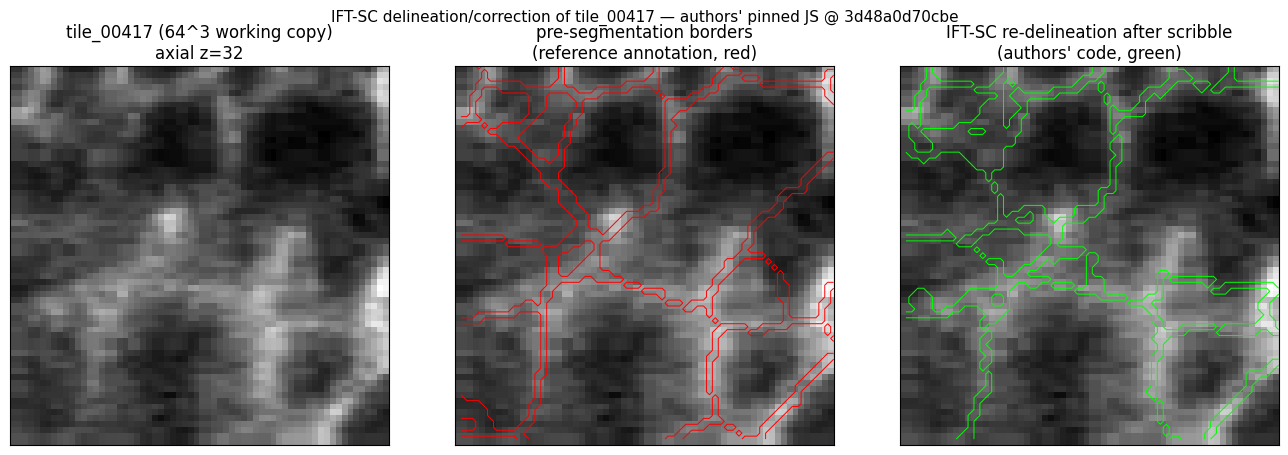

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

OUT = "/content/seg3d/out"
summary = json.load(open(f"{OUT}/summary.json"))
pre64 = np.fromfile(f"{OUT}/preseg64.raw", dtype=np.uint8).reshape(64, 64, 64)
res64 = np.fromfile(f"{OUT}/label64_corrected.raw", dtype=np.uint8).reshape(64, 64, 64)
img = np.fromfile("/content/seg3d/repo/data/tile_00417.raw", dtype=np.uint8).reshape(60, 60, 60)

# nearest-neighbor 60^3 -> 64^3 (display only, matches the app's label scaling)
zi = (np.arange(64) * 60 // 64)
img64 = img[np.ix_(zi, zi, zi)]


def borders(lbl):
    b = np.zeros(lbl.shape, bool)
    b[:-1, :, :] |= lbl[:-1, :, :] != lbl[1:, :, :]
    b[:, :-1, :] |= lbl[:, :-1, :] != lbl[:, 1:, :]
    b[:, :, :-1] |= lbl[:, :, :-1] != lbl[:, :, 1:]
    return b


z = 32
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
axes[0].imshow(img64[z].T, cmap="gray", origin="lower")
axes[0].set_title("tile_00417 (64^3 working copy)\naxial z=32")
axes[1].imshow(img64[z].T, cmap="gray", origin="lower")
axes[1].contour(borders(pre64)[z].T.astype(float), levels=[0.5], colors="red", linewidths=0.7, origin="lower")
axes[1].set_title("pre-segmentation borders\n(reference annotation, red)")
axes[2].imshow(img64[z].T, cmap="gray", origin="lower")
axes[2].contour(borders(res64)[z].T.astype(float), levels=[0.5], colors="lime", linewidths=0.7, origin="lower")
axes[2].set_title("IFT-SC re-delineation after scribble\n(authors\' code, green)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("IFT-SC delineation/correction of tile_00417 — authors\' pinned JS @ " + COMMIT[:12], fontsize=11)
fig.tight_layout()
plt.savefig("/content/seg3d/delineation_result.png", dpi=110, bbox_inches="tight")
plt.show()

### Per-region agreement table and CSV export — 領域ごとの一致度表

Computes the Dice table in the 64³ working space and exports it as CSV inside the Colab VM
(`/content/seg3d/out/region_dice.csv`).
**領域ごとの Dice を表と CSV で出力します。**

In [ ]:
import numpy as np
import pandas as pd

OUT = "/content/seg3d/out"
pre64 = np.fromfile(f"{OUT}/preseg64.raw", dtype=np.uint8).reshape(64, 64, 64)
before = np.fromfile(f"{OUT}/label64.raw", dtype=np.uint8).reshape(64, 64, 64)
after = np.fromfile(f"{OUT}/label64_corrected.raw", dtype=np.uint8).reshape(64, 64, 64)

rows = []
for lb in np.unique(pre64):
    if lb == 0:
        continue
    a = pre64 == lb
    b0 = before == lb
    b1 = after == lb
    denom0, denom1 = a.sum() + b0.sum(), a.sum() + b1.sum()
    rows.append({
        "region_label": int(lb),
        "voxels_pre": int(a.sum()),
        "dice_before": round(float((b0 & a).sum() * 2 / denom0), 4) if denom0 else np.nan,
        "dice_after_correction": round(float((b1 & a).sum() * 2 / denom1), 4) if denom1 else np.nan,
    })
df = pd.DataFrame(rows)
df.to_csv(f"{OUT}/region_dice.csv", index=False)
print("regions = %d | mean Dice before = %.4f | after one scribble correction = %.4f (worst region %d)"
      % (len(df), df.dice_before.mean(), df.dice_after_correction.mean(), summary["worst_region_label"]))
print("voxels differing from the pre-segmentation at 60^3 (contiguous ids):",
      summary["voxels_differing_from_preseg_60"])
df

regions = 43 | mean Dice before = 0.5811 | after one scribble correction = 0.5906 (worst region 23)
voxels differing from the pre-segmentation at 60^3 (contiguous ids): 76854


,region_label,voxels_pre,dice_before,dice_after_correction
0,1,12749,0.6072,0.6072
1,2,2063,0.8386,0.8386
2,3,214,0.5587,0.5587
3,4,1930,0.8691,0.8691
4,5,189,0.5765,0.5765
5,6,5555,0.8021,0.8021
6,7,11611,0.7353,0.7353
7,8,404,0.1339,0.1339
8,9,2076,0.2611,0.2611
9,10,8016,0.8800,0.8800


## Interpretation, differences from the paper, validation record — 解釈と論文との差分

**What was executed:** the authors' pinned IFT-SC implementation (commit `3d48a0d7`) delineating the embedded
sample `tile_00417` (60³ → 64³ working copy) from seeds at the geodesic centers of its own pre-segmentation,
following the app's *resume-a-pre-segmentation* code path (`loadLabelFile` → `delineate`), plus one
demonstrated DIFT-SC scribble correction on the worst-agreement region. Runtime: CPU-only; total downloads
< 1 MB.

**Differences from the paper / omissions:**
- The published version (§2.1) describes gradient-based arc weights; the released interface builds the
  delineation forest directly on the raw tile because `images.json` ships **no gradient file** for this tile
  (`Cose3D.createScene` falls back to `cur_img_data.img`). We follow the released code, which is the only
  executable definition of the method for this sample.
- No WebGL UI, no scribble drawing, no Django server, no STAPLE consensus, no user study: single-tile
  algorithmic demonstration only. The sphere-seed expansion replicates the app's scribble semantics without
  the mesh layer.
- The paper's pre-segmentations came from a companion CNN supervoxel method (its ref [2]) not included in
  the repository; here the shipped pre-segmentation is used as-is.
- The shipped pre-segmentation has sparse label ids while `iftGeodesicCenters` requires contiguous ids
  (its own docstring: *"an image labelled from 0 to n"*); the driver relabels values to 1..43 before
  seeding. Without this documented-precondition fix, the released code injects one bogus seed per missing
  id (verified in a diagnostic run), which is clearly not the intended operation.

**Validation record (this run):** fresh Colab CPU runtime; all 19 files verified by Git blob
SHA-1 and size against commit `3d48a0d7`; node driver exited 0; per-region Dice table above; result volumes
at `/content/seg3d/out/`. Free-tier Colab availability and runtimes may differ.

**References:** paper DOI 10.1109/ISBI.2018.8363600 · arXiv:1710.09933v1 · code
`bzjin/SEGMENT3D` @ `3d48a0d70cbebf3740e89b798b327facf6881dea` (no LICENSE file; terms rest with authors) ·
sample data `data/tile_00417.raw` + `data/tile_pre_seg_00417.raw` from the same commit.
**本ノートブックは部分再現（1 タイル、CPU 実行）であり、論文のデータセット規模の結果を検証するものでは
ありません。**